# Wake iteration sensitivity plot

`wake_iter_sensitivity.copy.csv` を読み込み、横軸を wake iteration、縦軸を空力係数・空力微係数としてプロットする。

この notebook は可視化専用であり、OpenVSP / VSPAERO は実行しない。

## 1. import と入力CSV

CSV は以下の順で探す。

1. notebook と同じディレクトリ
2. `examples/notebooks/wake_iter_sensitivity/`
3. `examples/scripts/wake_iter_sensitivity/`
4. 親ディレクトリ以下の同名CSV

配置が異なる場合は `csv_path` を直接書き換える。

In [111]:
from pathlib import Path
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, AutoMinorLocator, ScalarFormatter

plt.rcParams["mathtext.fontset"] = "stix"

candidate_paths = [
    Path("wake_iter_sensitivity.copy.csv"),
    Path("wake_iter_sensitivity/wake_iter_sensitivity.copy.csv"),
    Path("../scripts/wake_iter_sensitivity/wake_iter_sensitivity.copy.csv"),
    Path("../scripts/wake_iter_sensitivity/wake_iter_sensitivity.csv"),
    Path("../notebooks/wake_iter_sensitivity/wake_iter_sensitivity.copy.csv"),
]

csv_path = None
for candidate_path in candidate_paths:
    if candidate_path.exists():
        csv_path = candidate_path
        break

if csv_path is None:
    matches = sorted(Path.cwd().rglob("wake_iter_sensitivity.copy.csv"))
    if matches:
        csv_path = matches[0]

if csv_path is None:
    raise FileNotFoundError(
        "wake_iter_sensitivity.copy.csv was not found. "
        "Place it next to this notebook or set csv_path manually."
    )

output_dir = Path("wake_iter_sensitivity_plots")
output_dir.mkdir(parents=True, exist_ok=True)

print("csv_path:", csv_path.resolve())
print("output_dir:", output_dir.resolve())

csv_path: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\wake_iter_sensitivity\wake_iter_sensitivity.copy.csv
output_dir: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\wake_iter_sensitivity\wake_iter_sensitivity_plots


## 2. CSV読込と前処理

`passed` 列がある場合は、成功ケースだけをプロット対象にする。

In [112]:
df_raw = pd.read_csv(csv_path)
df = df_raw.copy()

if "wake_iter" not in df.columns:
    raise KeyError("The CSV must contain a 'wake_iter' column.")

df = df.sort_values("wake_iter").reset_index(drop=True)

if "passed" in df.columns:
    if df["passed"].dtype == bool:
        passed_mask = df["passed"]
    else:
        passed_mask = df["passed"].astype(str).str.lower().isin(["true", "1", "yes"])
    df = df[passed_mask].copy().reset_index(drop=True)

wake_iters = df["wake_iter"].to_numpy(dtype=int)

print("rows:", len(df))
print("wake_iters:", wake_iters.tolist())
df.head()

rows: 23
wake_iters: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 25, 29, 32, 38, 40]


,wake_iter,passed,case_dir,vsp3_path,errors,warnings,elapsed_s,total_elapsed_s,compute_geometry_elapsed_s,vspaero_sweep_elapsed_s,...,CMn_Alpha,CMn_Beta,CMn_p,CMn_q,CMn_r,CMn_Mach,CMn_U,CMn_ConGrp_1,CMn_ConGrp_2,CMn_ConGrp_3
0,4,True,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,[],[],145.174315,145.172893,0.245994,144.735511,...,-0.000360,0.033441,-0.067111,-0.007839,-0.035085,-0.000048,-4.800000e-06,0.001475,-0.000655,-0.038193
1,5,True,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,[],[],187.798496,187.797272,0.214094,187.329644,...,-0.019040,0.009457,-0.068170,-0.023006,-0.034626,-0.000074,-7.400000e-06,0.000553,-0.001544,-0.038566
2,6,True,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,[],[],218.782340,218.781072,0.257848,218.258551,...,0.002983,0.032308,-0.067116,0.001158,-0.034371,0.000015,1.500000e-06,0.002035,0.000019,-0.038573
3,7,True,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,[],[],253.384955,253.383605,0.239576,252.921958,...,0.011597,0.039928,-0.066449,0.003566,-0.035757,0.000012,1.200000e-06,0.003252,0.001353,-0.038296
4,8,True,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,[],[],271.132287,271.130780,0.236425,270.700605,...,-0.003786,0.027664,-0.067600,-0.001514,-0.035172,-0.000001,-1.000000e-07,0.002066,0.000115,-0.038105


## 3. $C_Y$ 系列を作る

VSPAERO の `.stab` では横力係数が `CS` として出る。ここでは、一般的な機体軸の横力係数として表示するため、

$$
C_Y = -C_D \sin\beta + C_S \cos\beta
$$

で `CY_*` 列を作る。今回のCSVでは `Beta_deg = 0` なので多くの列はほぼ `CS_*` と一致するが、`CY_Beta` は base の $C_D$ と $C_S$ の寄与を含める。

In [113]:
beta0 = np.deg2rad(df["Beta_deg"].to_numpy(dtype=float)) if "Beta_deg" in df.columns else np.zeros(len(df))

required_base = {"CD_Base", "CS_Base"}
missing_base = required_base - set(df.columns)
if missing_base:
    raise KeyError(f"Missing required columns for CY_Base: {sorted(missing_base)}")

df["CY_Base"] = -df["CD_Base"] * np.sin(beta0) + df["CS_Base"] * np.cos(beta0)

# Derivatives except Beta: beta0 is fixed, so only CD_* and CS_* terms are needed.
for suffix in ["U", "Alpha", "p", "q", "r", "Mach", "ConGrp_1", "ConGrp_2", "ConGrp_3"]:
    cd_col = f"CD_{suffix}"
    cs_col = f"CS_{suffix}"
    cy_col = f"CY_{suffix}"
    if cd_col in df.columns and cs_col in df.columns:
        df[cy_col] = -df[cd_col] * np.sin(beta0) + df[cs_col] * np.cos(beta0)

# d/dβ[-CD sinβ + CS cosβ]
if {"CD_Base", "CD_Beta", "CS_Base", "CS_Beta"}.issubset(df.columns):
    df["CY_Beta"] = (
        -df["CD_Base"] * np.cos(beta0)
        -df["CD_Beta"] * np.sin(beta0)
        +df["CS_Beta"] * np.cos(beta0)
        -df["CS_Base"] * np.sin(beta0)
    )

cy_columns = [column for column in df.columns if column.startswith("CY_")]
cy_columns

['CY_Base',
 'CY_U',
 'CY_Alpha',
 'CY_p',
 'CY_q',
 'CY_r',
 'CY_Mach',
 'CY_ConGrp_1',
 'CY_ConGrp_2',
 'CY_ConGrp_3',
 'CY_Beta']

## 4. `ConGrp_*` と $\delta_e, \delta_a, \delta_r$ の対応

`ConGrp_1`, `ConGrp_2`, `ConGrp_3` は、モデル内の Control Surface Group の順番に依存する。CSV の `control_groups` から対応を読む。

In [114]:
def read_control_groups(value):
    if isinstance(value, dict):
        return value
    if pd.isna(value):
        return {}
    return ast.literal_eval(str(value))

control_groups = {}
if "control_groups" in df.columns and df["control_groups"].notna().any():
    control_groups = read_control_groups(df.loc[df["control_groups"].notna(), "control_groups"].iloc[0])

# Fallback is the G103A convention used in the current model.
delta_to_congrp = {
    "delta_a": "ConGrp_1",
    "delta_e": "ConGrp_2",
    "delta_r": "ConGrp_3",
}

for congrp, group_name in control_groups.items():
    name = str(group_name).upper()
    if "AILERON" in name:
        delta_to_congrp["delta_a"] = congrp
    elif "ELEVATOR" in name:
        delta_to_congrp["delta_e"] = congrp
    elif "RUDDER" in name:
        delta_to_congrp["delta_r"] = congrp

print("control_groups:", control_groups)
print("delta_to_congrp:", delta_to_congrp)

control_groups: {'ConGrp_1': 'AILERON_GROUP', 'ConGrp_2': 'ELEVATOR_GROUP', 'ConGrp_3': 'RUDDER_GROUP'}
delta_to_congrp: {'delta_a': 'ConGrp_1', 'delta_e': 'ConGrp_2', 'delta_r': 'ConGrp_3'}


## 5. プロット用の共通処理

この notebook では、データ範囲に合わせて縦軸を自動拡大しない。

`wake_iter` 感度を過大に見せないため、各係数ごとに技術的に妥当な `y_range` を固定する。
すべての `y_range` は必ず 0 を含める。

x軸の範囲やtickは明示的に設定しない。

In [115]:
Y_RANGES = {
    # Base aerodynamic coefficients.
    "CL_Base": (0.0, 0.60),
    "CY_Base": (-0.005, 0.005),
    "CD_Base": (0.0, 0.025),
    "CMl_Base": (-0.005, 0.005),
    "CMm_Base": (-0.10, 0.0),
    "CMn_Base": (-0.005, 0.005),

    # Longitudinal derivatives: U.
    "CL_U": (0.0, 0.010),
    "CD_U": (0.0, 0.0010),
    "CMm_U": (-0.0010, 0.0),

    # Longitudinal derivatives: alpha, beta.
    "CL_Alpha": (0.0, 7.0),
    "CD_Alpha": (0.0, 0.25),
    "CMm_Alpha": (-1.5, 0.0),
    "CL_Beta": (-0.30, 0.30),
    "CD_Beta": (-0.02, 0.02),
    "CMm_Beta": (-1.0, 1.0),

    # Longitudinal derivatives: reduced rates.
    "CL_p": (-0.10, 0.10),
    "CD_p": (-0.02, 0.02),
    "CMm_p": (-0.20, 0.20),
    "CL_q": (0.0, 12.0),
    "CD_q": (-1.0, 0.0),
    "CMm_q": (-30.0, 0.0),
    "CL_r": (-0.20, 0.20),
    "CD_r": (-0.02, 0.02),
    "CMm_r": (-0.30, 0.30),

    # Longitudinal derivatives: control groups.
    "CL_ConGrp_1": (-0.10, 0.10),
    "CD_ConGrp_1": (-0.01, 0.01),
    "CMm_ConGrp_1": (-0.10, 0.10),
    "CL_ConGrp_2": (0.0, 0.5),
    "CD_ConGrp_2": (0.0, 0.02),
    "CMm_ConGrp_2": (-2.0, 0.0),
    "CL_ConGrp_3": (-0.10, 0.10),
    "CD_ConGrp_3": (-0.01, 0.01),
    "CMm_ConGrp_3": (-0.20, 0.20),

    # Lateral-directional derivatives: U.
    "CY_U": (-0.001, 0.001),
    "CMl_U": (-0.001, 0.001),
    "CMn_U": (-0.001, 0.001),

    # Lateral-directional derivatives: alpha, beta.
    "CY_Alpha": (-0.30, 0.30),
    "CMl_Alpha": (-0.05, 0.05),
    "CMn_Alpha": (-0.05, 0.05),
    "CY_Beta": (-0.30, 0.0),
    "CMl_Beta": (-0.10, 0.0),
    "CMn_Beta": (0.0, 0.06),

    # Lateral-directional derivatives: reduced rates.
    "CY_p": (-0.25, 0.0),
    "CMl_p": (-0.80, 0.0),
    "CMn_p": (-0.10, 0.0),
    "CY_q": (-0.10, 0.50),
    "CMl_q": (-0.10, 0.10),
    "CMn_q": (-0.10, 0.10),
    "CY_r": (0.0, 0.25),
    "CMl_r": (0.0, 0.15),
    "CMn_r": (-0.06, 0.0),

    # Lateral-directional derivatives: control groups.
    "CY_ConGrp_1": (-0.10, 0.0),
    "CMl_ConGrp_1": (-0.50, 0.0),
    "CMn_ConGrp_1": (-0.01, 0.02),
    "CY_ConGrp_2": (-0.02, 0.02),
    "CMl_ConGrp_2": (-0.02, 0.02),
    "CMn_ConGrp_2": (-0.02, 0.02),
    "CY_ConGrp_3": (0.0, 0.20),
    "CMl_ConGrp_3": (0.0, 0.02),
    "CMn_ConGrp_3": (-0.06, 0.0),
}

bad_ranges = {
    column: y_range
    for column, y_range in Y_RANGES.items()
    if not (y_range[0] <= 0.0 <= y_range[1])
}
if bad_ranges:
    raise ValueError(f"All y-ranges must include zero: {bad_ranges}")


def format_axis(ax, column):
    if column not in Y_RANGES:
        raise KeyError(f"Y_RANGES does not define a y-range for {column!r}.")

    ax.set_ylim(*Y_RANGES[column])
    ax.set_xlim(left=0.0)

    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(formatter)

    ax.grid(True, which="major", linewidth=0.5)
    ax.grid(True, which="minor", linewidth=0.3, alpha=0.4)
    # 両方の軸の指数表記を解除する場合
    ax.ticklabel_format(style="plain", useOffset=False)

def plot_column(ax, column, ylabel):
    if column not in df.columns:
        ax.text(0.5, 0.5, f"missing\n{column}", ha="center", va="center", transform=ax.transAxes)
        ax.set_ylabel(ylabel)
        return

    ax.plot(df["wake_iter"], df[column], marker="o", linewidth=1.5, markerfacecolor="none")
    ax.set_ylabel(ylabel)
    format_axis(ax, column)

## 6. Base 空力係数

3行2列で、左列を $C_L, C_Y, C_D$、右列を $C_l, C_m, C_n$ にする。タイトルは付けない。

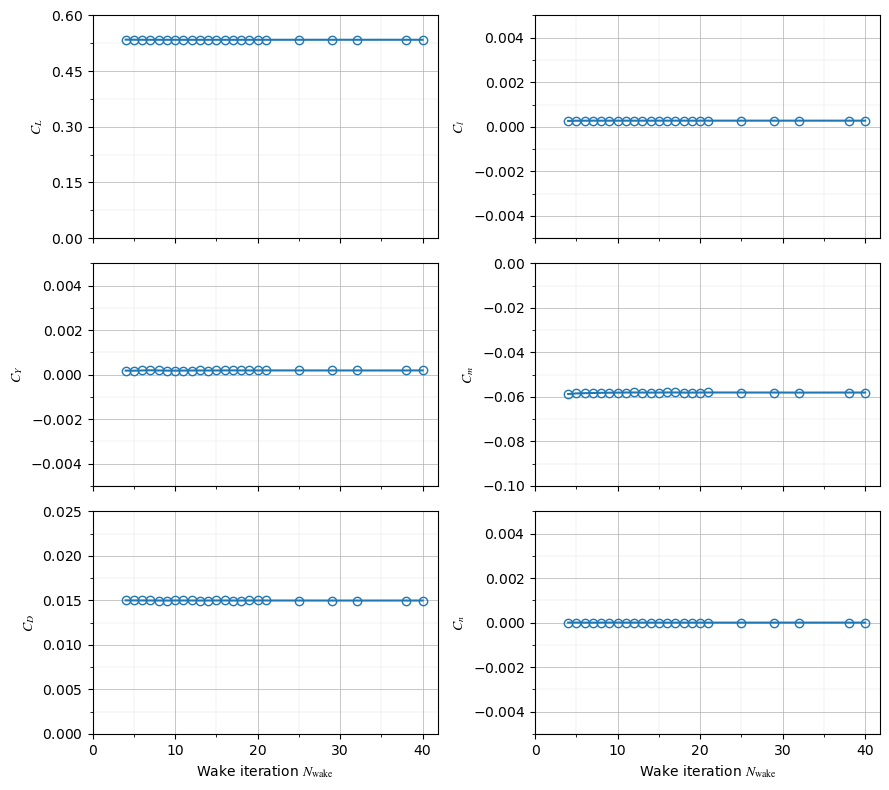

In [116]:
base_panels = [
    ("CL_Base", r"$C_L$"),
    ("CMl_Base", r"$C_l$"),
    ("CY_Base", r"$C_Y$"),
    ("CMm_Base", r"$C_m$"),
    ("CD_Base", r"$C_D$"),
    ("CMn_Base", r"$C_n$"),
]

fig, axes = plt.subplots(3, 2, figsize=(9, 8), sharex=True)
for ax, (column, ylabel) in zip(axes.flat, base_panels):
    plot_column(ax, column, ylabel)

for ax in axes[-1, :]:
    ax.set_xlabel(r"Wake iteration $N_{\mathrm{wake}}$")

fig.tight_layout()
fig.savefig(output_dir / "wake_iter_base.png", dpi=200, bbox_inches="tight")
fig.savefig(output_dir / "wake_iter_base.pdf", bbox_inches="tight")
plt.show()

## 7. 縦の空力微係数

列は左から $C_L, C_D, C_m$、行は上から $U, \alpha, \beta, \hat p, \hat q, \hat r, \delta_e, \delta_a, \delta_r$ とする。

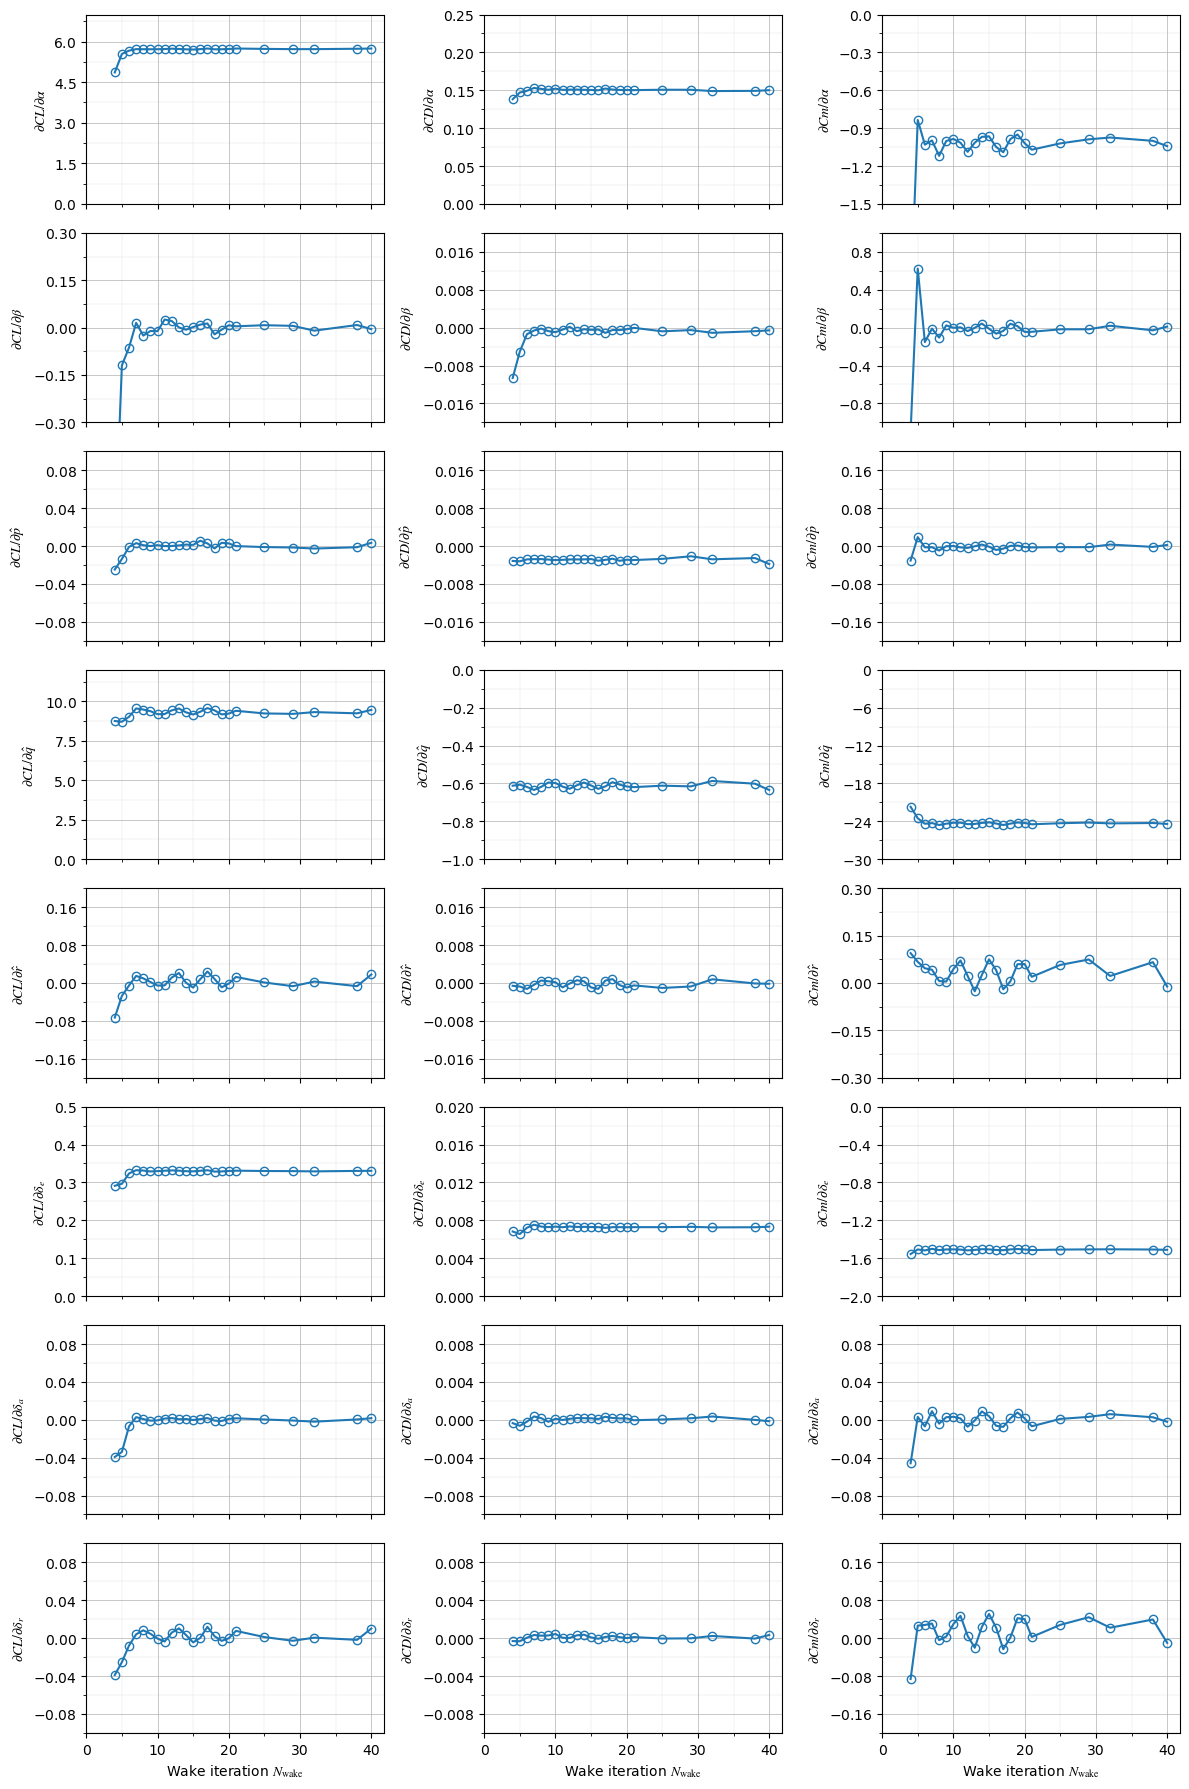

In [117]:
derivative_rows = [
    # ("U", r"U"),
    ("Alpha", r"\alpha"),
    ("Beta", r"\beta"),
    ("p", r"\hat{p}"),
    ("q", r"\hat{q}"),
    ("r", r"\hat{r}"),
    (delta_to_congrp["delta_e"], r"\delta_e"),
    (delta_to_congrp["delta_a"], r"\delta_a"),
    (delta_to_congrp["delta_r"], r"\delta_r"),
]

longitudinal_columns = [
    ("CL", r"CL"),
    ("CD", r"CD"),
    ("CMm", r"Cm"),
]

fig, axes = plt.subplots(len(derivative_rows), len(longitudinal_columns), figsize=(12, 18), sharex=True)

for row_index, (suffix, variable_label) in enumerate(derivative_rows):
    for col_index, (prefix, coefficient_label) in enumerate(longitudinal_columns):
        column = f"{prefix}_{suffix}"
        ylabel = rf"$\partial {coefficient_label}/\partial {variable_label}$"
        plot_column(axes[row_index, col_index], column, ylabel)

for ax in axes[-1, :]:
    ax.set_xlabel(r"Wake iteration $N_{\mathrm{wake}}$")

fig.tight_layout()
fig.savefig(output_dir / "wake_iter_longitudinal_derivatives.png", dpi=200, bbox_inches="tight")
fig.savefig(output_dir / "wake_iter_longitudinal_derivatives.pdf", bbox_inches="tight")
plt.show()

## 8. 横・方向の空力微係数

列は左から $C_Y, C_l, C_n$、行は上から $U, \alpha, \beta, \hat p, \hat q, \hat r, \delta_e, \delta_a, \delta_r$ とする。

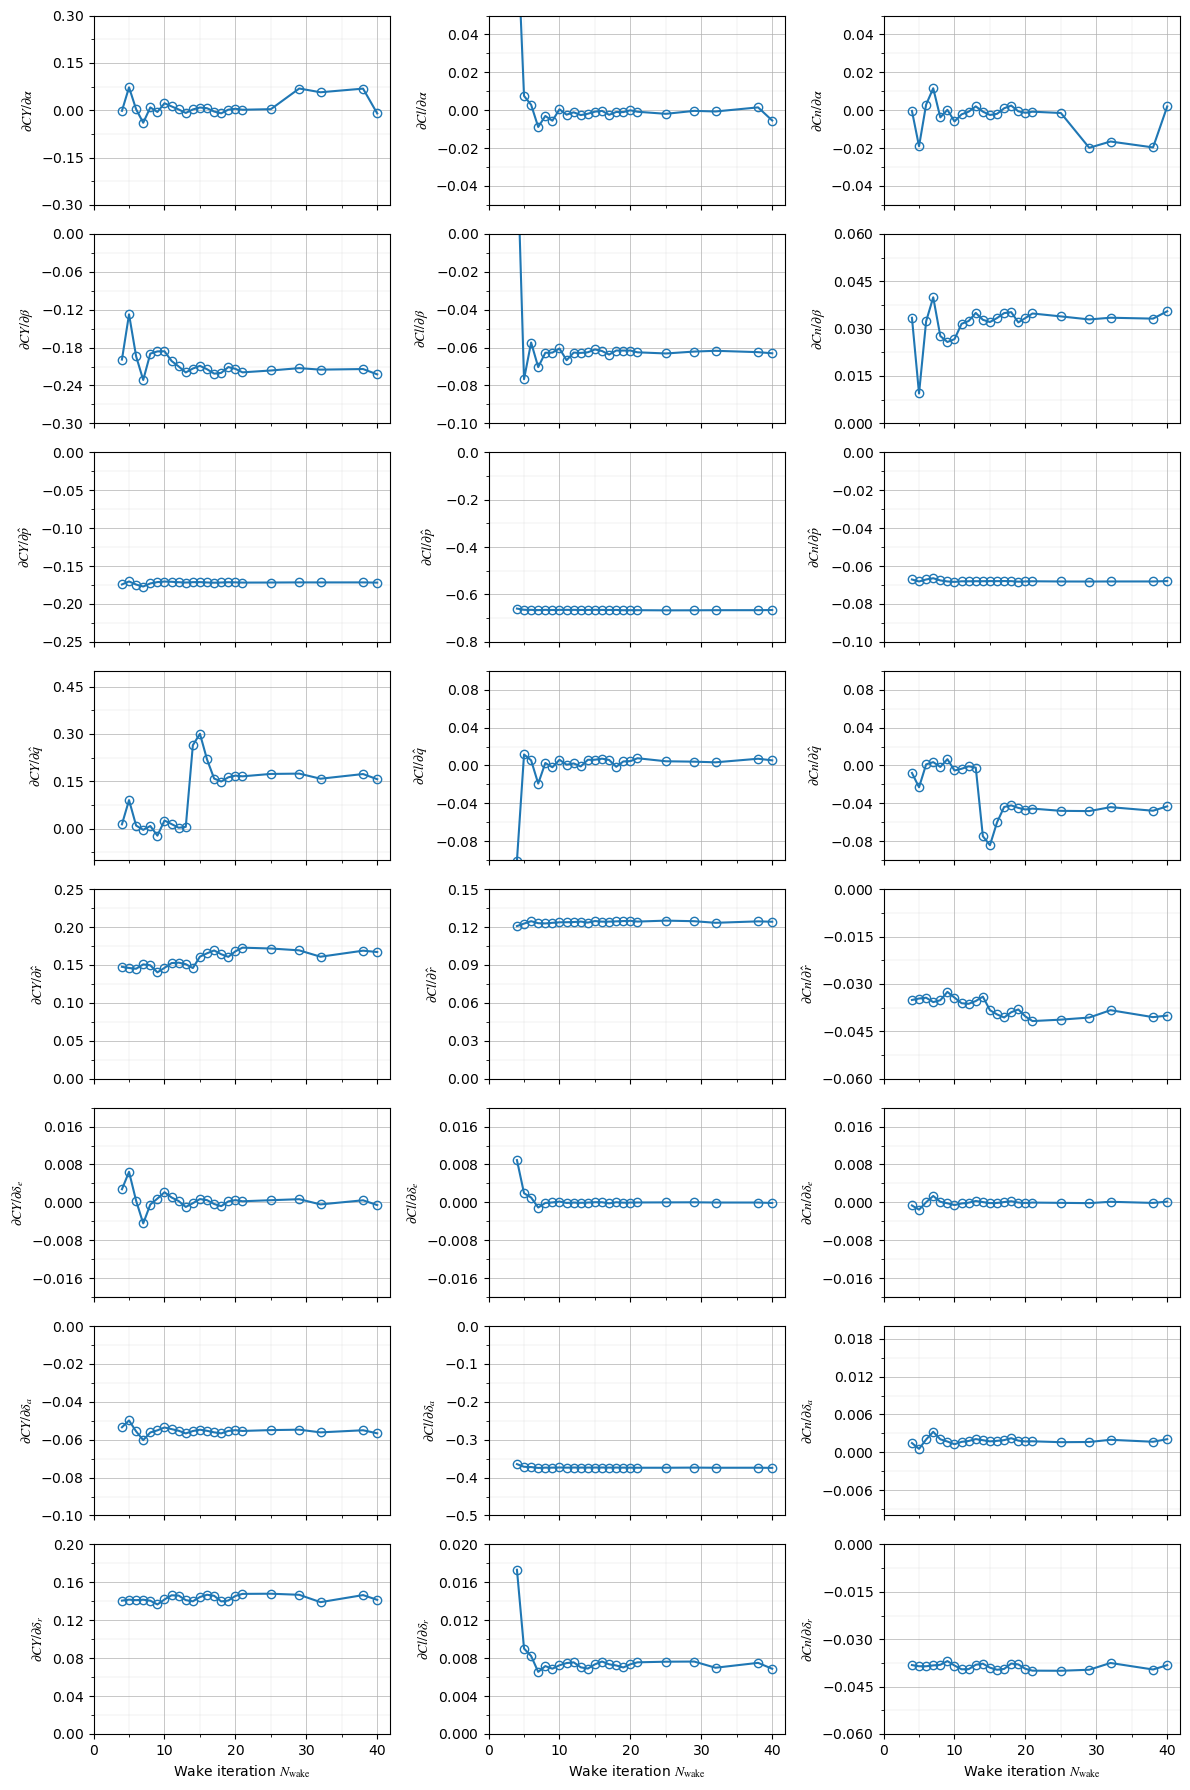

In [118]:
lateral_columns = [
    ("CY", r"CY"),
    ("CMl", r"Cl"),
    ("CMn", r"Cn"),
]

fig, axes = plt.subplots(len(derivative_rows), len(lateral_columns), figsize=(12, 18), sharex=True)

for row_index, (suffix, variable_label) in enumerate(derivative_rows):
    for col_index, (prefix, coefficient_label) in enumerate(lateral_columns):
        column = f"{prefix}_{suffix}"
        ylabel = rf"$\partial {coefficient_label}/\partial {variable_label}$"
        plot_column(axes[row_index, col_index], column, ylabel)

for ax in axes[-1, :]:
    ax.set_xlabel(r"Wake iteration $N_{\mathrm{wake}}$")

fig.tight_layout()
fig.savefig(output_dir / "wake_iter_lateral_derivatives.png", dpi=200, bbox_inches="tight")
fig.savefig(output_dir / "wake_iter_lateral_derivatives.pdf", bbox_inches="tight")
plt.show()

## 9. 出力ファイル

生成した図は `wake_iter_sensitivity_plots/` に保存される。

In [119]:
for path in sorted(output_dir.glob("wake_iter_*")):
    print(path)

wake_iter_sensitivity_plots\wake_iter_base.pdf
wake_iter_sensitivity_plots\wake_iter_base.png
wake_iter_sensitivity_plots\wake_iter_lateral_derivatives.pdf
wake_iter_sensitivity_plots\wake_iter_lateral_derivatives.png
wake_iter_sensitivity_plots\wake_iter_longitudinal_derivatives.pdf
wake_iter_sensitivity_plots\wake_iter_longitudinal_derivatives.png
